# 03 - Risk Analysis and Feature Engineering

## Credit Risk Modelling Using Logistic Regression

This notebook compares observed serious-delinquency rates across borrower groups and creates two candidate features for the logistic model. The group rates are unadjusted sample associations, not causal effects or borrower-specific PD estimates.

## Objective and definitions

The target SeriousDlqin2yrs equals 1 when serious delinquency occurs within two years. For a borrower group $B$, the observed rate is

$$
\widehat{P}(Y=1\mid X\in B)
=
\frac{\text{serious-delinquency outcomes in }B}
     {\text{borrowers in }B}.
$$

We examine age, income, debt ratio, revolving utilization, delinquency history, open credit lines, and dependents. We then examine two candidate features for modelling: total prior delinquencies and log(1 + MonthlyIncome). We do not fit a predictive model in this notebook.

In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

sys.path.insert(0, "../src")
from feature_engineering import add_features
from evaluation import default_rate_by_bin

DATA_PATH = "../data/processed/cleaned_data.csv"
FIG_PATH = "../reports/figures/03_default_rates.png"
TARGET = "SeriousDlqin2yrs"

clean_data = pd.read_csv(DATA_PATH)
print(f"Loaded cleaned data: {clean_data.shape[0]:,} borrowers, {clean_data.shape[1]:,} variables")
print(f"Observed target default rate: {clean_data[TARGET].mean() * 100:.3f}%")

Loaded cleaned data: 145,562 borrowers, 11 variables
Observed target default rate: 6.754%


## 1. Default rates across meaningful ranges

The bins are chosen to show broad risk patterns and retain tail groups for scrutiny. Each result includes borrower and event counts so that high or irregular rates in small groups are visible. Bin intervals are left-closed and right-open.

In [2]:
risk_bins = {
    "age": [0, 25, 35, 45, 55, 65, 75, np.inf],
    "MonthlyIncome": [0, 1, 2000, 4000, 6000, 10000, 15000, 25000, np.inf],
    "DebtRatio": [0, 0.1, 0.25, 0.5, 1, 2, 5, 25, 100, np.inf],
    "RevolvingUtilizationOfUnsecuredLines": [0, 0.1, 0.3, 0.5, 0.75, 1, 2, 5, np.inf],
    "TotalDelinquencies": [0, 1, 2, 3, 5, 10, 20, np.inf],
    "NumberOfOpenCreditLinesAndLoans": [0, 1, 3, 6, 10, 15, 20, np.inf],
    "NumberOfDependents": [0, 1, 2, 3, 4, 5, np.inf],
}
features = add_features(clean_data)
rate_tabs = {}
for feature, bins in risk_bins.items():
    rate_tabs[feature] = default_rate_by_bin(features, feature, bins, TARGET)
    print(f"Observed default rate by {feature}:")
    display(rate_tabs[feature])

Observed default rate by age:


,bin,borrowers,defaults,default_rate_percent
0,"[0.0, 25.0)",1769,195,11.023
1,"[25.0, 35.0)",16750,1890,11.284
2,"[35.0, 45.0)",28238,2561,9.069
3,"[45.0, 55.0)",36135,2806,7.765
4,"[55.0, 65.0)",33301,1618,4.859
5,"[65.0, 75.0)",19010,543,2.856
6,"[75.0, inf)",10359,218,2.104


Observed default rate by MonthlyIncome:


,bin,borrowers,defaults,default_rate_percent
0,"[0.0, 1.0)",1616,65,4.022
1,"[1.0, 2000.0)",9178,847,9.229
2,"[2000.0, 4000.0)",27399,2549,9.303
3,"[4000.0, 6000.0)",28848,2140,7.418
4,"[6000.0, 10000.0)",58736,3374,5.744
5,"[10000.0, 15000.0)",14076,591,4.199
6,"[15000.0, 25000.0)",4399,197,4.478
7,"[25000.0, inf)",1310,68,5.191


Observed default rate by DebtRatio:


...

,bin,borrowers,defaults,default_rate_percent
0,"[0.0, 1.0)",115772,3208,2.771
1,"[1.0, 2.0)",16912,2058,12.169
2,"[2.0, 3.0)",5851,1406,24.030
3,"[3.0, 5.0)",4423,1664,37.622
4,"[5.0, 10.0)",2202,1238,56.222
5,"[10.0, 20.0)",194,132,68.041
6,"[20.0, inf)",208,125,60.096


Observed default rate by NumberOfOpenCreditLinesAndLoans:


,bin,borrowers,defaults,default_rate_percent
0,"[0.0, 1.0)",1587,448,28.229
1,"[1.0, 3.0)",10105,1146,11.341
2,"[3.0, 6.0)",32141,2206,6.864
3,"[6.0, 10.0)",49666,2732,5.501
4,"[10.0, 15.0)",34746,2073,5.966
5,"[15.0, 20.0)",12204,855,7.006
6,"[20.0, inf)",5113,371,7.256


Observed default rate by NumberOfDependents:


,bin,borrowers,defaults,default_rate_percent
0,"[0.0, 1.0)",86392,5079,5.879
1,"[1.0, 2.0)",26314,1935,7.354
2,"[2.0, 3.0)",19520,1584,8.115
3,"[3.0, 4.0)",9483,837,8.826
4,"[4.0, 5.0)",2862,297,10.377
5,"[5.0, inf)",991,99,9.990


## 2. Compare risk profiles visually

The panels use the same group rates as the tables. The logarithmic delinquency axis keeps the upper tail visible; counts remain available in the tables above. These are unadjusted, one-variable group comparisons.

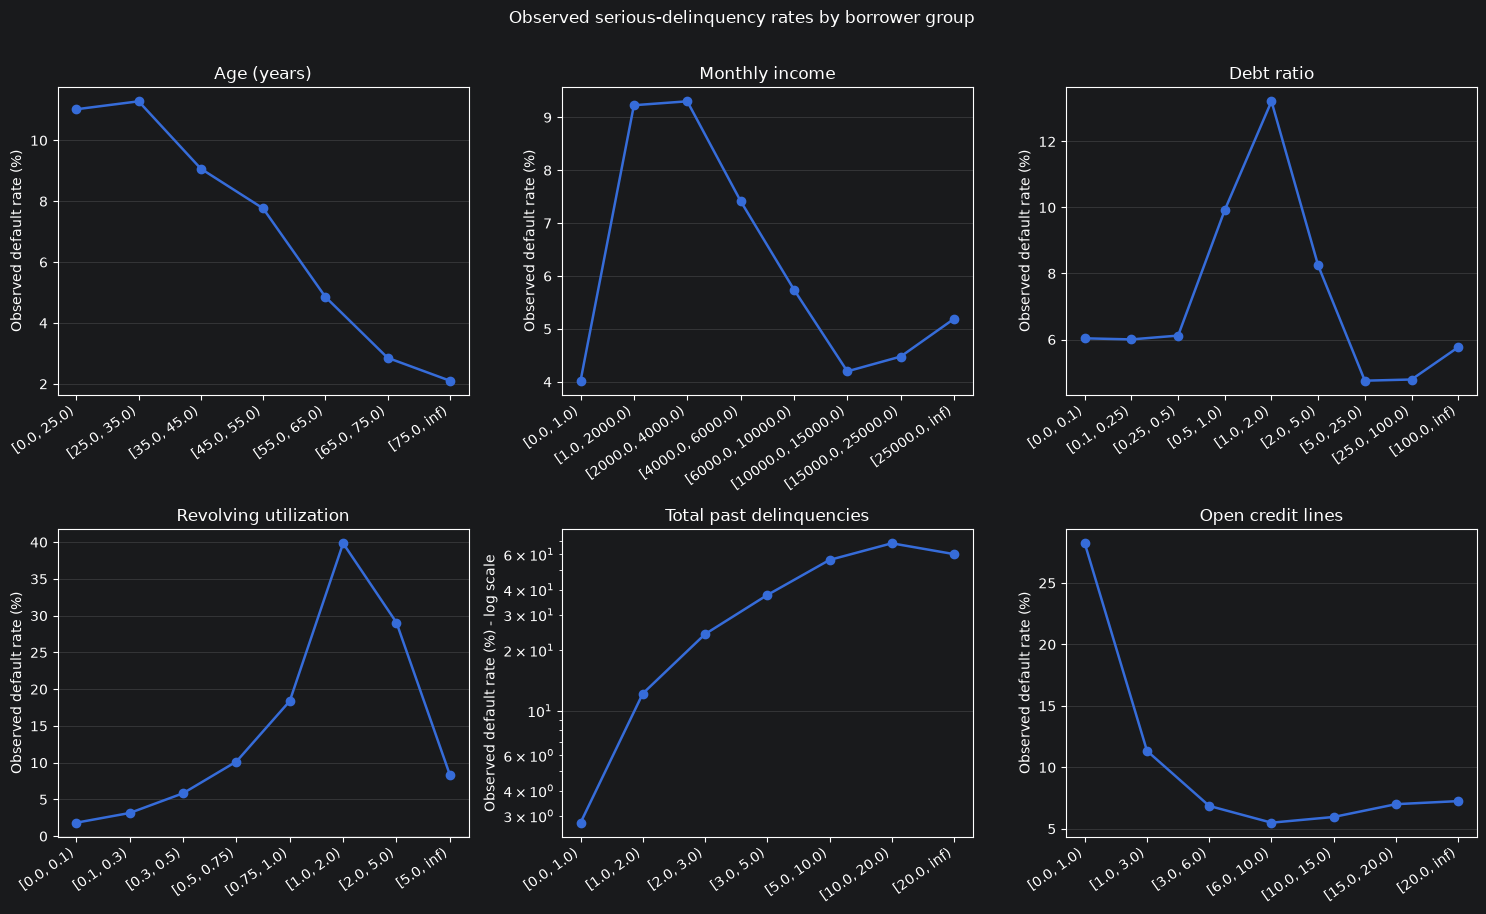

Saved figure to ../reports/figures/03_default_rates.png


In [3]:
plot_cols = [
    ("age", "Age (years)"),
    ("MonthlyIncome", "Monthly income"),
    ("DebtRatio", "Debt ratio"),
    ("RevolvingUtilizationOfUnsecuredLines", "Revolving utilization"),
    ("TotalDelinquencies", "Total past delinquencies"),
    ("NumberOfOpenCreditLinesAndLoans", "Open credit lines"),
]
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for ax, (feature, title) in zip(axes.flat, plot_cols):
    tab = rate_tabs[feature]
    vals = tab["default_rate_percent"].to_numpy()
    labels = tab["bin"].astype(str).to_list()
    ax.plot(np.arange(len(vals)), vals, marker="o", linewidth=1.8)
    ax.set_title(title)
    ax.set_ylabel("Observed default rate (%)")
    ax.set_xticks(np.arange(len(labels)))
    ax.set_xticklabels(labels, rotation=35, ha="right")
    ax.grid(axis="y", alpha=0.25)
axes[1, 1].set_yscale("log")
axes[1, 1].set_ylabel("Observed default rate (%) - log scale")
fig.suptitle("Observed serious-delinquency rates by borrower group", y=1.01)
fig.tight_layout()
import os
os.makedirs("../reports/figures", exist_ok=True)
fig.savefig(FIG_PATH, dpi=160, bbox_inches="tight")
plt.show()
print(f"Saved figure to {FIG_PATH}")

## 3. Engineer and inspect two candidate features

### Total delinquencies

The three supplied past-due counters measure related aspects of prior repayment difficulty. Their row-wise sum gives one measure of prior delinquency history. The original counts remain in the feature table, but Notebook 04 uses the sum instead of the three correlated counts.

### Log income

Monthly income is strongly right-skewed. `log(1 + income)` compresses the high-income tail while preserving zero income. We compare skewness on this cleaned sample, where missing incomes have already been mean-imputed. That imputation affects the distribution, so these skewness values are descriptive rather than a final modelling decision.

In [4]:
income_skew = pd.Series({
    "MonthlyIncome": features["MonthlyIncome"].skew(),
    "LogMonthlyIncome": features["LogMonthlyIncome"].skew(),
})
display(income_skew.rename("skewness").to_frame().round(3))

delin_stats = features["TotalDelinquencies"].describe(
    percentiles=[0.50, 0.75, 0.90, 0.95, 0.99]
).to_frame("TotalDelinquencies")
display(delin_stats.round(3))

freq_total = features["TotalDelinquencies"].value_counts().sort_index().head(12)
display(freq_total.rename("borrowers").to_frame())
print(f"Maximum TotalDelinquencies: {features['TotalDelinquencies'].max():,.0f}")
print(
    "Records with all three source delinquency counters above 20:",
    int(features[
        features["NumberOfTime30-59DaysPastDueNotWorse"].gt(20)
        & features["NumberOfTime60-89DaysPastDueNotWorse"].gt(20)
        & features["NumberOfTimes90DaysLate"].gt(20)
    ].shape[0]),
)

,skewness
MonthlyIncome,125.48
LogMonthlyIncome,-4.87


,TotalDelinquencies
count,145562.000
mean,0.826
std,11.140
min,0.000
50%,0.000
75%,0.000
90%,1.000
95%,2.000
99%,6.000
max,294.000


,borrowers
TotalDelinquencies,
0,115772
1,16912
2,5851
3,2851
4,1572
5,928
6,583
7,376
8,192


Maximum TotalDelinquencies: 294
Records with all three source delinquency counters above 20: 208


## Findings and interpretation

- Observed default rates rise with prior delinquency: from about **2.8%** for borrowers with no recorded past-due events to **12.2%** with one, **24.0%** with two, **37.6%** with three or four, and **56.2%** with five to nine. Groups with 10 or more events are small and rates become less stable; the rate is not monotonic in the extreme tail.
- In ordinary utilization ranges, rates rise from about **1.8%** below 0.1 utilization to **18.4%** in [0.75, 1). Above 1, rates and sample counts become irregular, so those tail values should not be treated as a smooth continuation.
- Observed rates generally decline with age, from approximately **11.0%** below age 25 to **2.1%** at age 75 and above, with a modest rise in the 25–34 group relative to under 25.
- Income and debt ratio have less regular patterns. Income-group rates generally fall from low/mid income bands, with some rise in upper bands. Debt-ratio rates rise around 0.5–2, then vary across very large values. These variables may need a flexible representation if later diagnostics support it.
- Open credit lines and dependents have less regular rate patterns than delinquency history, utilization, and age. The group with no open lines has a higher observed rate (**28.2%**, n=1,587) than groups with one or more, so that first band warrants separate scrutiny. Group rates alone do not account for other borrower characteristics.
- `LogMonthlyIncome` substantially reduces the extreme positive skew in `MonthlyIncome`; it does not guarantee a symmetric distribution, particularly with the retained zero-income mass and mean-imputed observations.
- There are 208 records with all three delinquency counters above 20. The maximum total-delinquency count is 294. These records were retained; the data definition should be checked before setting any exclusion rule.

All rates are unadjusted group comparisons and do not account for other borrower characteristics.